Number of images: 278
Image shape: (64, 64)


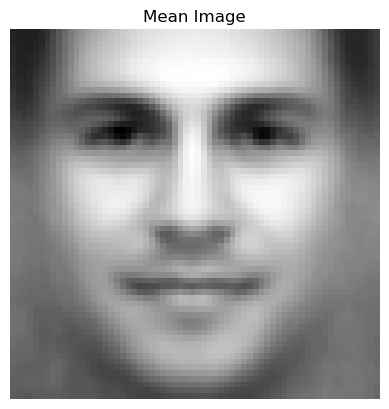

In [1]:
# MEAN IMAGE

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

folder = "subset_300_white_men_20_35"

images = []
image_names = []
expected_shape = None

for filename in sorted(os.listdir(folder)):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        path = os.path.join(folder, filename)

        img = Image.open(path).convert("L")
        img = np.array(img, dtype=float)

        if expected_shape is None:
            expected_shape = img.shape
        elif img.shape != expected_shape:
            raise ValueError(
                f"Image '{filename}' has shape {img.shape}, "
                f"expected {expected_shape}. All images must be the same size."
            )

        images.append(img)
        image_names.append(filename)

images = np.array(images)

mean_image = np.mean(images, axis=0)

print("Number of images:", len(images))
print("Image shape:", mean_image.shape)

plt.imshow(mean_image, cmap="gray")
plt.axis("off")
plt.title("Mean Image")
plt.show()

In [2]:
#PCA

from sklearn.decomposition import PCA

centered_images = images - mean_image

n_images, height, width = centered_images.shape
X = centered_images.reshape(n_images, height * width)

pca = PCA()
X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of relevant components:", n_components)

PCA shape: (278, 278)
Number of relevant components: 87


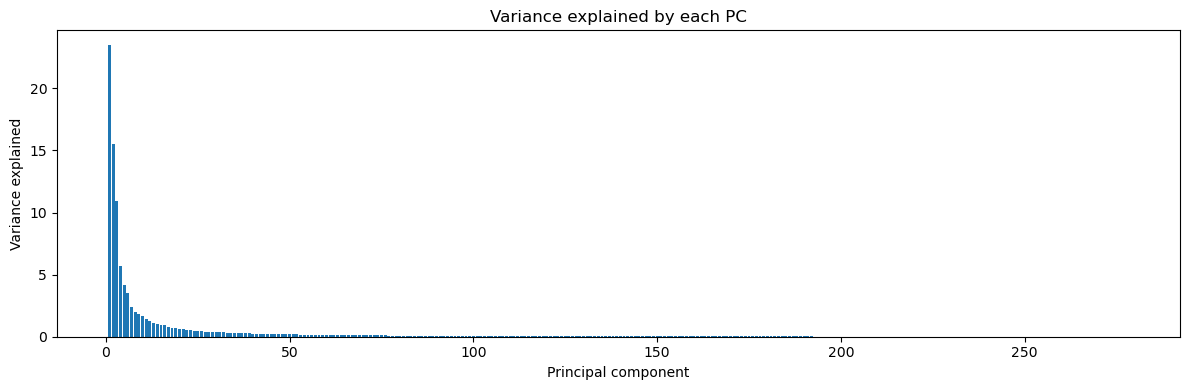

In [3]:
#BOX PLOT OF PC'S EXPLAINED VARIANCE

fig, ax1 = plt.subplots(figsize=(12, 4))

pc_numbers = np.arange(1, len(pca.explained_variance_ratio_) + 1)
ax1.bar(pc_numbers, pca.explained_variance_ratio_ * 100)
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained")


plt.title("Variance explained by each PC")
plt.tight_layout()
plt.show()

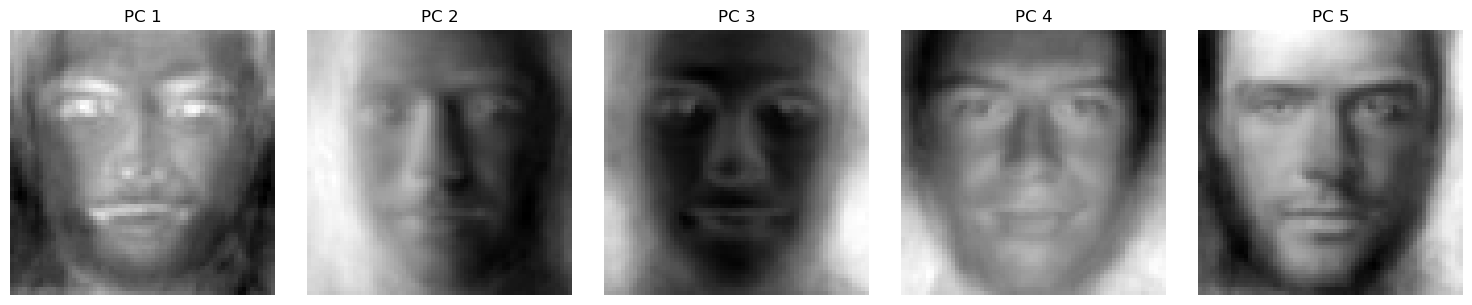

In [4]:
#FIVE MOST VARIED PC'S

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    pc_image = pca.components_[i].reshape(height, width)
    axes[i].imshow(pc_image, cmap="gray")
    axes[i].set_title(f"PC {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

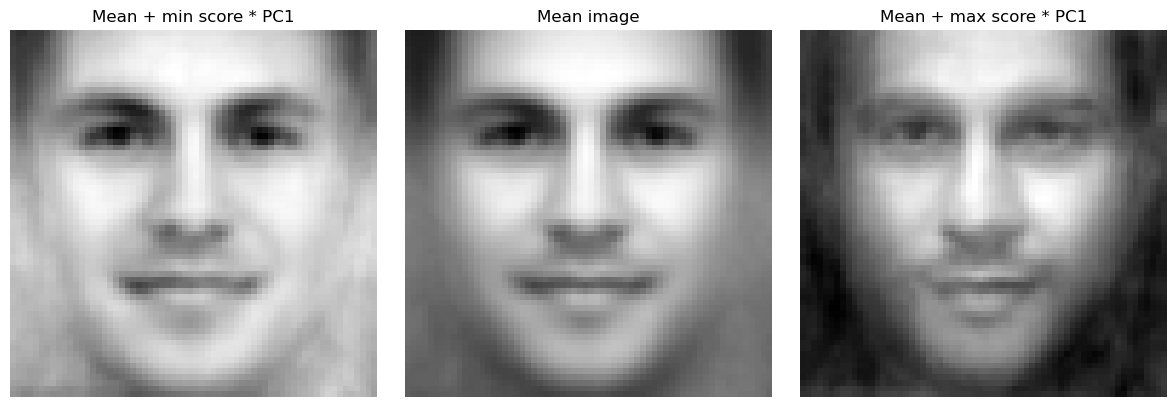

In [5]:
#MIN/MAX OF EACH PC + MEAN IMAGE

pc_index = 0

pc = pca.components_[pc_index].reshape(height, width)
scores = X_pca[:, pc_index]

min_score = np.min(scores)
max_score = np.max(scores)

img_min = mean_image + min_score * pc
img_mean = mean_image
img_max = mean_image + max_score * pc

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_min, cmap="gray")
axes[0].set_title(f"Mean + min score * PC{pc_index+1}")
axes[0].axis("off")

axes[1].imshow(img_mean, cmap="gray")
axes[1].set_title("Mean image")
axes[1].axis("off")

axes[2].imshow(img_max, cmap="gray")
axes[2].set_title(f"Mean + max score * PC{pc_index+1}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
#FIND MOST IMPORTANT PC'S

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.feature_selection import SequentialFeatureSelector

# Load ratings
df = pd.read_csv("average_ratings.csv")

# Only keep PCs explaining at least 95% variance
X_selected = X_pca[:, :n_components]

# Connect PCA scores to filenames
pc_df = pd.DataFrame(X_selected)
pc_df["Images"] = image_names

# Match PCA scores with ratings
data = df.merge(pc_df, on="Images")

#DATA LOOKS LIKE:
'''
Images      Rating    PC1     PC2     PC3    ...
face1.jpg    2.5      420     -38     120
face2.jpg    4.0     -190      72      40
face3.jpg    1.5       80     140     -93
'''

# Inputs and target
X = data.drop(columns=["Images", "average_rating"]).to_numpy()
y = data["average_rating"].to_numpy()

print("X:", X.shape)
print("y:", y.shape)

# Regression model
model = LinearRegression()

# 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Forward sequential feature selection
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select="auto",
    tol=0.005,
    direction="forward",
    scoring="r2",
    cv=cv
)

sfs.fit(X, y)

best_selected = np.where(sfs.get_support())[0]

print("Selected PCs:", best_selected + 1)
print("Number of selected PCs:", len(best_selected))

X: (256, 87)
y: (256,)
Selected PCs: [ 2  5  6  7  8  9 10 11 19 20 21 26 32 35 42 45 47 48 55 58 67 82]
Number of selected PCs: 22


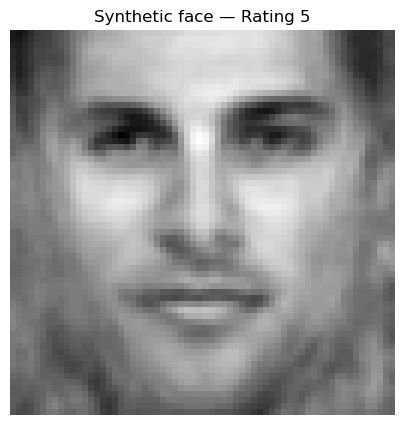

array([[ 63.18362382,  57.38274966,  62.50287056, ...,  77.58708683,
         89.66584534,  89.98595987],
       [ 62.01227751,  60.24196002,  67.17940981, ...,  77.33337153,
         87.07138361,  88.73169914],
       [ 65.47224841,  64.1396479 ,  70.41014605, ...,  78.73844351,
         85.68863082,  89.46801709],
       ...,
       [100.53657772,  97.75485753,  93.76742782, ..., 119.66373883,
        108.35085896, 104.60930109],
       [ 98.88080604,  93.19758687,  88.45024412, ..., 112.86775227,
        106.21622884, 101.91485911],
       [ 94.43998048,  89.47457259,  89.45235853, ..., 108.16511212,
        106.54873383, 102.11125303]])

In [7]:
#GENERATE FACE

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Fit final model using the PCs selected by forward selection
final_model = LinearRegression()
final_model.fit(X[:, best_selected], y)

beta = final_model.coef_
intercept = final_model.intercept_

def generate_face(rating, show=True):
    pc_scores = ((rating - intercept) / np.sum(beta**2)) * beta

    # Start from the average face
    face = mean_image.flatten().copy()

    # Add the selected PCs with their calculated scores
    for score, pc_index in zip(pc_scores, best_selected):
        face += score * pca.components_[pc_index]

    # Turn back into an image
    face = face.reshape(height, width)

    # Keep pixel values valid
    face = np.clip(face, 0, 255)

    if show:
        plt.figure(figsize=(5, 5))
        plt.imshow(face, cmap="gray")
        plt.title(f"Synthetic face — Rating {rating}")
        plt.axis("off")
        plt.show()

    return face

generate_face(5)

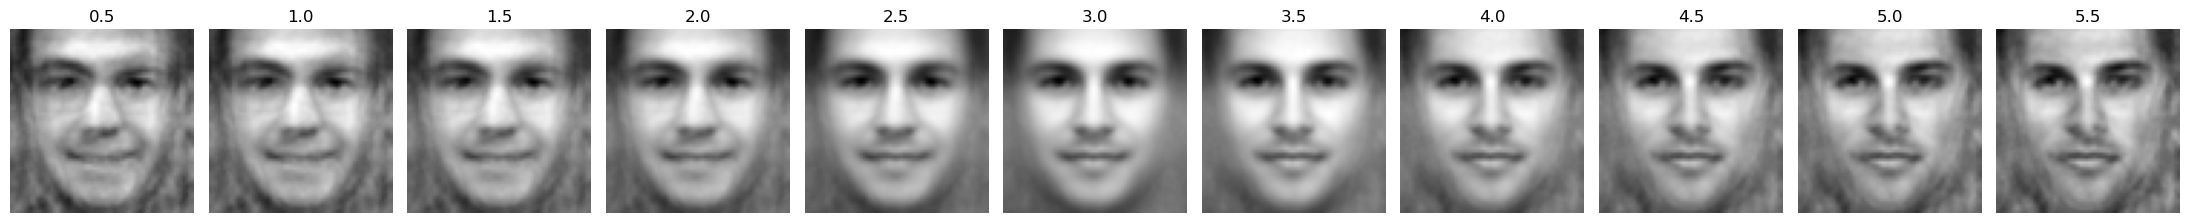

In [8]:
#GENERATE MORE FACES

ratings = np.arange(0.5, 5.5 + 0.5, 0.5)

fig, axes = plt.subplots(1, len(ratings), figsize=(22, 4))

for ax, rating in zip(axes, ratings):
    face = generate_face(rating, show=False)

    ax.imshow(face, cmap="gray")
    ax.set_title(f"{rating}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Minimum predicted rating: 1.225
Maximum predicted rating: 5.225

New synthetic ratings:
[1.225 1.625 2.025 2.425 2.825 3.225 3.625 4.025 4.425 4.825 5.225]


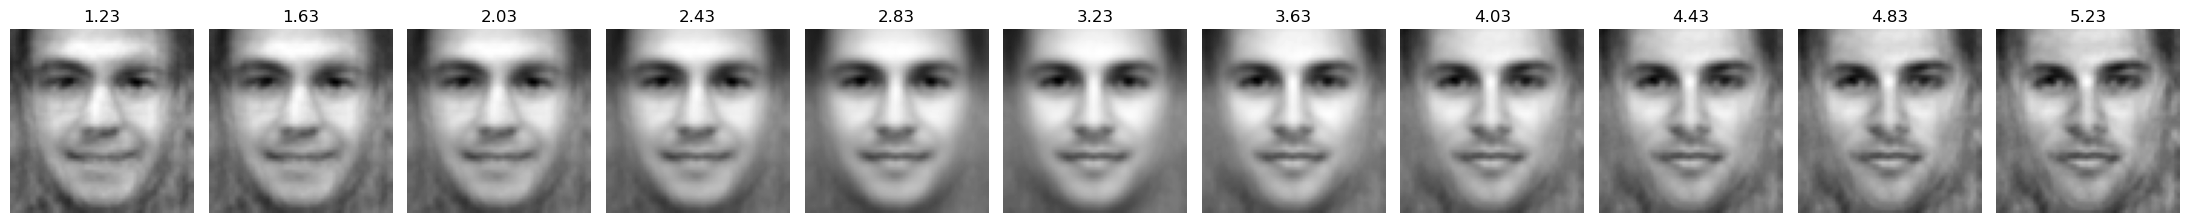

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#Fit final model with best PCs
final_model = LinearRegression()
final_model.fit(X[:, best_selected], y)


# PCA scores for all original images
X_original = pc_df.drop(columns=["Images"]).to_numpy()


# Keep only the PCs selected by forward selection
X_original_selected = X_original[:, best_selected]


# Predict rating for every original face
predicted_ratings = final_model.predict(X_original_selected)


# Find prediction range
min_rating = predicted_ratings.min()
max_rating = predicted_ratings.max()

print(f"Minimum predicted rating: {min_rating:.3f}")
print(f"Maximum predicted rating: {max_rating:.3f}")


#Generate 11 new ratings
target_ratings = np.linspace(min_rating, max_rating, 11)

print("\nNew synthetic ratings:")
print(np.round(target_ratings, 3))


#Generate new synthetic faces
beta = final_model.coef_
intercept = final_model.intercept_

def make_synthetic_face(rating):

    # Find PC scores that produce the requested rating
    pc_scores = ((rating - intercept) / np.sum(beta**2)) * beta

    # Begin with the average image
    face = mean_image.flatten().copy()

    # Add contributions from selected PCs
    for score, pc_index in zip(pc_scores, best_selected):
        face += score * pca.components_[pc_index]

    face = face.reshape(height, width)

    return np.clip(face, 0, 255)


#Display faces
fig, axes = plt.subplots(1, 11, figsize=(22, 4))

for ax, rating in zip(axes, target_ratings):

    face = make_synthetic_face(rating)

    ax.imshow(face, cmap="gray")
    ax.set_title(f"{rating:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import os
import numpy as np
from PIL import Image

# Create output folder
output_folder = "synthetic_images"
os.makedirs(output_folder, exist_ok=True)

for rating in target_ratings:
    # Generate the synthetic face for this rating
    face = make_synthetic_face(rating)

    # Convert to uint8 so it can be saved as JPG
    face_uint8 = face.astype(np.uint8)

    for i in range(1, 11):
        filename = f"syn_img_{i}_{rating:.2f}.jpg"
        filepath = os.path.join(output_folder, filename)

        img = Image.fromarray(face_uint8)
        img.save(filepath)

print(f"Saved synthetic images in folder: {output_folder}")

Saved synthetic images in folder: synthetic_images
